# Four interrogation signals: updated fin-whale and seismic models


The whale disturbance is a deliberately simple, noiseless simulation.
It contains no spreading loss, environmental interference, pressure-to-strain
conversion, cable response, cable motion, or added noise.

The Gaussian width, sine-squared note taper, spatial-shift coefficient, and
\(0.8\)-radian phase scale are transparent simulation choices. They are not
measurements from the whale papers.


In [1]:
# NumPy handles the arrays and numerical calculations, while Matplotlib makes the figures.
import numpy as np
import matplotlib.pyplot as plt

# fftconvolve computes the return and matched filter efficiently using FFTs.
from scipy.signal import fftconvolve

# Use the same default figure size throughout the notebook.
plt.rcParams["figure.figsize"] = (10, 5)
np.set_printoptions(precision=5, suppress=True)

## 1. Fiber parameters and the four interrogation signals

This uses the same corrected physical travel-time convention as the larger comparison notebook.


In [2]:
# --- Fiber geometry and sampling ---
# These values define the simulated 1000-km cable and the speed of light inside it.
fiber_length_km = 1000.0
refractive_index = 1.468
speed_of_light_m_per_s = 299_792_458.0
# Light travels more slowly in fiber, so divide the vacuum speed by the refractive index.
speed_in_fiber_m_per_s = speed_of_light_m_per_s/refractive_index

# --- Interrogation-signal parameters ---
f_0 = 0.0
# Illustrative chirp rate chosen so the pulse contains about three cycles.
gamma = 2.5e7
alpha = 3.5e-6

# Convert the cable length to meters before computing the one-way travel time.
fiber_length_m = 1000.0*fiber_length_km
T_oneway = fiber_length_m/speed_in_fiber_m_per_s

# The restored whale model varies on a broad, illustrative spatial scale,
# so the original 1-km cable grid is sufficient for this comparison.
num_ranges = 1001
# tau is the one-way delay coordinate. Multiplying by the speed in fiber converts it to position.
tau = np.linspace(0.0, T_oneway, num_ranges)
z_km = tau*speed_in_fiber_m_per_s/1000.0

# The measured return uses round-trip time, so fast_time is 2*tau.
fast_time = 2.0*tau
dt_tau = tau[1]-tau[0]
dt_fast = fast_time[1]-fast_time[0]
spatial_spacing_m = 1000.0*(z_km[1]-z_km[0])

# Each interrogation signal is transmitted for one tenth of the one-way travel time.
t_pulse_end = 0.1*T_oneway


def pulse_window(values, t, pulse_end):
    """Keep the signal only during the transmitted pulse."""
    return np.where((t >= 0.0) & (t <= pulse_end), values, 0.0)


def linear_chirp(t, pulse_end):
    """Generate a signal whose frequency increases linearly in time."""
    # Integrating f(t) = f_0 + gamma*t gives the phase in cycles.
    phase_cycles = f_0*t+0.5*gamma*t**2
    return pulse_window(np.exp(2j*np.pi*phase_cycles), t, pulse_end)


def pure_tone(t, pulse_end):
    """Generate one constant frequency for the whole pulse."""
    # Use the chirp's midpoint frequency for a direct comparison.
    frequency = f_0+0.5*gamma*pulse_end
    return pulse_window(np.exp(2j*np.pi*frequency*t), t, pulse_end)


def complex_fourier_signal(t, pulse_end, coefficients):
    """Add the selected Fourier modes and then apply the pulse window."""
    # Each coefficient controls the amplitude and initial phase of one deterministic frequency.
    # Sum positive-frequency complex exponentials with complex weights.
    values = np.zeros_like(t, dtype=complex)
    for mode, coefficient in enumerate(coefficients, start=1):
        values += coefficient*np.exp(
            2j*np.pi*mode*t/pulse_end
        )
    return pulse_window(values, t, pulse_end)


# These four fixed coefficients make a small Fourier example that is easy to reproduce.
# They were chosen for this comparison and are not fitted data.
four_term_coefficients = np.array([
    1.00+0.00j,
    0.50+0.40j,
    0.25-0.20j,
    0.10+0.10j,
])

# Draw 20 random complex coefficients once. The seed makes the exact signal reproducible.
# Their magnitudes and initial phases are both random.
rng_signal = np.random.default_rng(5)
twenty_term_coefficients = (
    rng_signal.normal(size=20)
    + 1j*rng_signal.normal(size=20)
)/np.sqrt(2.0)

# Store the four generators together so every later calculation uses the same loop and settings.
signal_functions = {
    "Linear chirp": linear_chirp,
    "Pure tone": pure_tone,
    "Four-term Complex Fourier": (
        lambda t, T: complex_fourier_signal(
            t,
            T,
            four_term_coefficients,
        )
    ),
    "Twenty-term Complex Fourier": (
        lambda t, T: complex_fourier_signal(
            t,
            T,
            twenty_term_coefficients,
        )
    ),
}


def sample_normalized_signal(signal_function):
    """Sample one pulse and scale its discrete energy to one."""
    # Equal energy keeps a larger starting amplitude from giving one signal an unfair advantage.
    number_samples = int(np.floor(t_pulse_end/dt_fast))+1
    pulse_time = np.arange(number_samples)*dt_fast
    samples = signal_function(pulse_time, t_pulse_end)
    energy = np.sum(np.abs(samples)**2)*dt_fast
    return pulse_time, samples/np.sqrt(energy)


signal_samples = {
    name: sample_normalized_signal(function)
    for name, function in signal_functions.items()
}

print("Four signals created:", list(signal_samples))


Four signals created: ['Linear chirp', 'Pure tone', 'Four-term Complex Fourier', 'Twenty-term Complex Fourier']


## 2. The four transmitted signals

These are the complex interrogation waveforms supplied to the simulated
fiber. For each signal, the plot shows the unwrapped phase change

$$
\Delta\theta(t)
=
\operatorname{unwrap}\!\bigl(\arg c(t)\bigr)
-
\arg c(0).
$$

Thus, every curve begins at zero radians. The vertical axis shows how much
the phase of the complete complex signal has changed since the pulse began;
it does not show the real and imaginary parts separately.

For the linear chirp and pure tone, this phase change follows their analytic
phase directly. For each Fourier signal, it is the phase of the complete sum,
not the phase of an individual Fourier component. The curves are evaluated
on a dense plotting grid; the recovery calculation retains its own numerical
sampling grid.


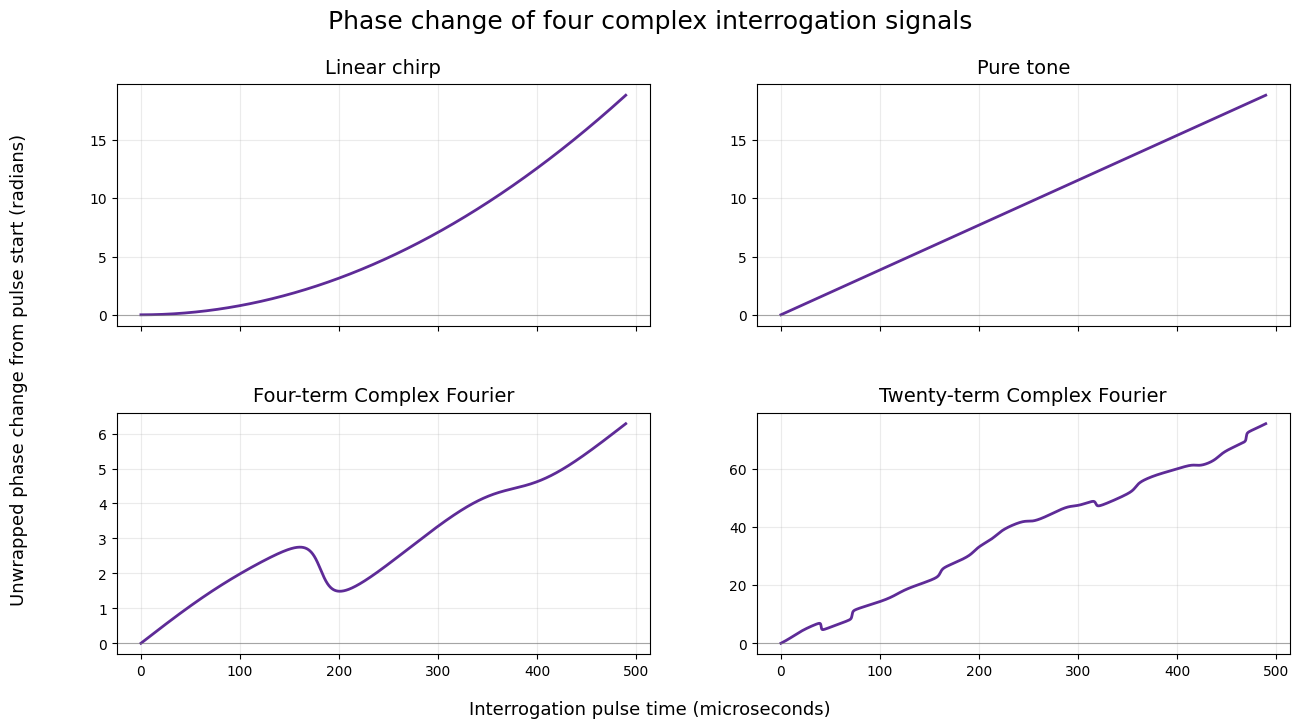

In [3]:
# This grid is only for making the phase plots smooth. The recovery
# calculation below still uses the original sampling grid.
signal_plot_points = 2001
signal_plot_time = np.linspace(
    0.0,
    t_pulse_end,
    signal_plot_points,
)

# Save the normalized signal and its phase change so either one can be
# inspected later without regenerating it.
signal_plot_samples = {}
signal_plot_phase_change = {}

for name, signal_function in signal_functions.items():
    # Evaluate one interrogation signal during the time when its pulse is on.
    values = signal_function(
        signal_plot_time,
        t_pulse_end,
    )

    # Give the plotted signals the same total energy. This does not change
    # their phase because the normalization factor is a positive real number.
    plot_energy = np.trapezoid(
        np.abs(values)**2,
        signal_plot_time,
    )
    normalized_values = values/np.sqrt(plot_energy)
    signal_plot_samples[name] = normalized_values

    # np.angle gives phase between -pi and pi. np.unwrap removes the
    # artificial jumps by 2*pi, and subtracting the first value makes each
    # curve show phase change from the start of the pulse.
    unwrapped_phase = np.unwrap(np.angle(normalized_values))
    signal_plot_phase_change[name] = (
        unwrapped_phase-unwrapped_phase[0]
    )


# Put one signal in each panel so their phase behavior is easy to compare.
fig, axes = plt.subplots(
    2,
    2,
    figsize=(13.333, 7.5),
    sharex=True,
)
axes = axes.ravel()

for ax, (name, phase_change) in zip(
    axes,
    signal_plot_phase_change.items(),
):
    ax.plot(
        signal_plot_time*1e6,
        phase_change,
        color="#5E2B97",
        linewidth=2.0,
    )
    ax.axhline(
        0.0,
        color="#777777",
        linewidth=0.8,
        alpha=0.6,
    )
    ax.set_title(name, fontsize=14, pad=8)
    ax.tick_params(labelsize=10)
    ax.grid(alpha=0.25)

# Use one title and one pair of shared axis labels instead of repeating them
# in all four panels.
fig.suptitle(
    "Phase change of four complex interrogation signals",
    fontsize=18,
    y=0.98,
)
fig.supxlabel(
    "Interrogation pulse time (microseconds)",
    fontsize=13,
    y=0.035,
)
fig.supylabel(
    "Unwrapped phase change from pulse start (radians)",
    fontsize=13,
    x=0.02,
)
fig.subplots_adjust(
    left=0.10,
    right=0.98,
    bottom=0.12,
    top=0.88,
    hspace=0.36,
    wspace=0.20,
)

# Save the same figure that appears in the notebook so it can also be used
# directly in the report or presentation.
fig.savefig(
    "OFDR_Interrogation_Signals_Phase_Change_2x2_preview.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()


## 3. Three synthetic perturbation families

All three disturbances are simulated. They are **not observations**.

### Simplified fin-whale song

For note type \(j\in\{H,L\}\), the code uses the hyperbolic downsweep and
the numerical frequency endpoints and durations reported in:

- Q. Goestchel, W. S. D. Wilcock, and S. Abadi, *Enhancing fin whale
  vocalizations in distributed acoustic sensing data* (2025):
  https://doi.org/10.1121/10.0036696

The alternating high/low start intervals come from the A--B song pattern
measured off Kauai in:

- T. A. Helble et al., *Fin Whale Song Patterns Shift Over Time in the
  Central North Pacific* (2020):
  https://doi.org/10.3389/fmars.2020.587110

The spatial whale disturbance is

$$
\boxed{
g_{\mathrm{whale}}(z,T)
=
0.8\,C(z)
\sum_{m=0}^{5}
\left[
P_H\!\bigl(u(z,T)-32m\bigr)
+
P_L\!\bigl(u(z,T)-(32m+20)\bigr)
\right].
}
$$

The Gaussian

$$
C(z)=\exp\left[-\frac12\left(\frac{z-500}{35}\right)^2\right]
$$

makes the disturbance strongest near 500 km and lets it fade smoothly away
from that region. The local coordinate

$$
u(z,T)=T-1-0.002(z-500)
$$

introduces the same slow spatial phase shift used in the original synthetic
model. It is a visualization rule, not a physical sound-speed law.

Each finite note also has a sine-squared taper, so it starts and ends at zero
instead of being abruptly cut off. The Gaussian, taper, spatial shift, and
\(0.8\)-radian scale are modeling choices; the hyperbolic note parameters and
the \(20/12\)-second timing are the paper-based parts.


In [4]:
# This is the selected display scale for the whale disturbance.
target_peak_phase = 0.8


def normalize_field(field, peak_phase):
    """Scale an illustrative field to a selected peak phase."""
    maximum = np.max(np.abs(field))
    if maximum == 0.0:
        raise ValueError("Cannot normalize a field whose maximum is zero.")
    return peak_phase*field/maximum


def hyperbolic_downsweep(
    x,
    f_start_hz,
    f_end_hz,
    duration_s,
):
    """Finite hyperbolic downsweep with a smooth simulation taper."""
    x = np.asarray(x, dtype=float)
    inside = (x >= 0.0) & (x <= duration_s)
    x_clipped = np.clip(x, 0.0, duration_s)

    # Integrating the hyperbolic frequency curve gives the phase in cycles.
    frequency_drop_hz = f_start_hz-f_end_hz
    phase_scale = (
        f_start_hz*f_end_hz*duration_s/frequency_drop_hz
    )
    phase_cycles = phase_scale*np.log1p(
        frequency_drop_hz*x_clipped
        / (f_end_hz*duration_s)
    )

    # This taper is retained from the original synthetic call_packet.
    # It is a modeling choice, not part of the cited whale fit.
    note_envelope = np.sin(np.pi*x_clipped/duration_s)**2
    note = note_envelope*np.cos(2*np.pi*phase_cycles)
    return np.where(inside, note, 0.0)


def P_H(x):
    """High note: 28.8 to 17.8 Hz in 0.68 seconds."""
    return hyperbolic_downsweep(
        x,
        f_start_hz=28.8,
        f_end_hz=17.8,
        duration_s=0.68,
    )


def P_L(x):
    """Low note: 21.8 to 14.7 Hz in 0.78 seconds."""
    return hyperbolic_downsweep(
        x,
        f_start_hz=21.8,
        f_end_hz=14.7,
        duration_s=0.78,
    )


# Six pairs means m = 0,...,5. High notes repeat every 32 seconds,
# and each low note begins 20 seconds after its paired high note.
M = 5
song_cycle_s = 32.0
low_note_offset_s = 20.0
whale_phase_amplitude_rad = 0.8


def S(t):
    """Six high/low fin-whale pairs with 20/12-second timing."""
    t = np.asarray(t, dtype=float)
    song = np.zeros_like(t)
    for m in range(M+1):
        song += P_H(t-song_cycle_s*m)
        song += P_L(
            t-(song_cycle_s*m+low_note_offset_s)
        )
    return song


def g_whale_temporal(t):
    """Noiseless temporal whale phase before spatial localization."""
    return whale_phase_amplitude_rad*S(t)


# Use a fine time grid here so each short whale note is smooth in the overview plot.
whale_time_step_s = 0.001
whale_song_end_s = (
    song_cycle_s*M+low_note_offset_s+0.78
)
whale_time_s = np.arange(
    0.0,
    whale_song_end_s+whale_time_step_s,
    whale_time_step_s,
)
whale_trace_rad = g_whale_temporal(whale_time_s)


# Localize the whale disturbance near the middle of the cable with the chosen Gaussian.
whale_center_km = 500.0
whale_gaussian_width_km = 35.0
whale_initial_delay_s = 1.0
whale_spatial_shift_s_per_km = 0.002

whale_distance_km = z_km-whale_center_km
whale_spatial_envelope = np.exp(
    -0.5*(whale_distance_km/whale_gaussian_width_km)**2
)

# Choose a fixed time when the third high note is visible near the center of the cable.
# At z = 500 km, this is 0.34 seconds into that note.
whale_snapshot_time_s = 65.34
whale_local_song_time_s = (
    whale_snapshot_time_s
    - whale_initial_delay_s
    - whale_spatial_shift_s_per_km*whale_distance_km
)
whale_field = (
    whale_phase_amplitude_rad
    * whale_spatial_envelope
    * S(whale_local_song_time_s)
)


def ricker_wavelet(relative_time, center_frequency_hz):
    """Use a Ricker pulse to represent one seismic arrival."""
    argument = np.pi*center_frequency_hz*relative_time
    return (1.0-2.0*argument**2)*np.exp(-argument**2)


def smooth_switch(time, center, transition_width):
    """Change smoothly from about zero to about one."""
    return 0.5*(1.0+np.tanh((time-center)/transition_width))


# ----------------------------------------------------------------
# 2. Seismic-like event at one spatial snapshot: P/S pulses and coda
# ----------------------------------------------------------------
# The source location and time origin are controlled simulation choices.
seismic_snapshot_time_s = 40.0
earthquake_location_km = 500.0
earthquake_start_s = 0.0

# Representative crustal wave speeds.
p_wave_speed_km_per_s = 6.0
s_wave_speed_km_per_s = 3.8

# Use one source-wavelet frequency for both arrivals. Qian and Yamanaka
# (2012) use a 0.25-Hz Ricker source in fluid-solid simulations.
# At 1-km spatial spacing, this gives several samples across the
# narrowest (S-wave) main lobe.
p_peak_frequency_hz = 0.25
s_peak_frequency_hz = 0.25

# Convert distance from the source into separate P- and S-wave arrival times.
seismic_distance_km = np.abs(z_km-earthquake_location_km)
p_arrival_s = (
    earthquake_start_s
    + seismic_distance_km/p_wave_speed_km_per_s
)
s_arrival_s = (
    earthquake_start_s
    + seismic_distance_km/s_wave_speed_km_per_s
)
# A relative time of zero means the center of that wave has reached the cable position.
p_relative_time = seismic_snapshot_time_s-p_arrival_s
s_relative_time = seismic_snapshot_time_s-s_arrival_s

# Regularized geometric-spreading proxy.  It is finite at d=0 and
# approaches an inverse-distance envelope for distances much larger
# than the selected 500-km scale.
distance_envelope = 500.0/(500.0+seismic_distance_km)

# Make the P-wave amplitude half the S-wave amplitude, as chosen for this simulation.
p_waveform = (
    0.50
    * distance_envelope
    * ricker_wavelet(p_relative_time, p_peak_frequency_hz)
)
s_waveform = (
    1.00
    * distance_envelope
    * ricker_wavelet(s_relative_time, s_peak_frequency_hz)
)

# One deliberately simple coda begins at the S-wave arrival.  A sine
# makes the tail oscillatory, while the exponential makes it fade.
# These three numerical values are transparent simulation choices.
coda_amplitude = 0.14
coda_decay_s = 28.0
coda_frequency_hz = 0.12
coda_relative_time = seismic_snapshot_time_s-s_arrival_s
coda_waveform = np.where(
    coda_relative_time >= 0.0,
    (
        coda_amplitude
        * distance_envelope
        * np.exp(-coda_relative_time/coda_decay_s)
        * np.sin(2*np.pi*coda_frequency_hz*coda_relative_time)
    ),
    0.0,
)

# This is a dimensionless waveform proxy, not calibrated displacement.
# The coda is a schematic tail rather than a calibrated earthquake coda.
seismic_waveform_proxy = p_waveform+s_waveform+coda_waveform

# A spatial derivative gives a strain-shaped DAS proxy.  The final
# 0.4-radian peak remains a normalization choice for this comparison.
z_m = z_km*1000.0
seismic_strain_proxy = np.gradient(
    seismic_waveform_proxy,
    z_m,
)
seismic_field = normalize_field(
    seismic_strain_proxy,
    peak_phase=0.4,
)


# ----------------------------------------------------------------
# 3. Temperature event with temporal switches fitted to OOI data
# ----------------------------------------------------------------
# Day 0 corresponds to April 27, 2019. The switch coefficients are
# rounded least-squares estimates from the selected OOI CTD record.
# The spatial Gaussian remains a simulation choice.
temperature_fit_day_zero = "2019-04-27"
temperature_snapshot_day = 16.7
temperature_center_km = 500.0
temperature_width_km = 100.0
temperature_turn_on_day = 5.2
temperature_turn_off_day = 26.3
temperature_rise_days = 3.3
temperature_fall_days = 2.7


def g_temperature(time_day, position_km):
    """Multiply the fitted time profile by the chosen spatial Gaussian."""
    spatial_profile = np.exp(
        -0.5*(
            (position_km-temperature_center_km)
            / temperature_width_km
        )**2
    )
    # Subtracting the off-switch from the on-switch creates one finite warming event.
    temporal_profile = (
        smooth_switch(
            time_day,
            temperature_turn_on_day,
            temperature_rise_days,
        )
        - smooth_switch(
            time_day,
            temperature_turn_off_day,
            temperature_fall_days,
        )
    )
    return spatial_profile*temporal_profile


# Day 16.7 is near the maximum of the fitted temporal profile.
# Treating this dimensionless shape directly as optical phase remains
# a simulation choice; no Celsius-to-radian calibration is applied.
temperature_field = g_temperature(
    temperature_snapshot_day,
    z_km,
)


# Keep each disturbance and its plotting limits in one dictionary so the same recovery code can be reused.
families = {
    "Whale-call-like": {
        "snapshot": whale_snapshot_time_s,
        "field": whale_field,
        "xlim": (0.0, fiber_length_km),
        "recovery_xlim": (350.0, 650.0),
        "context": (
            "Fixed simulation time: 65.34 s; "
            "Gaussian width: 35 km"
        ),
    },
    "Seismic-like": {
        "snapshot": seismic_snapshot_time_s,
        "field": seismic_field,
        "xlim": (0.0, fiber_length_km),
        "recovery_xlim": (0.0, fiber_length_km),
        "context": (
            "T = 40 s; z0 = 500 km; t0 = 0 s"
        ),
    },
    "Temperature-like": {
        "snapshot": temperature_snapshot_day,
        "field": temperature_field,
        "xlim": (0.0, fiber_length_km),
        "recovery_xlim": (0.0, fiber_length_km),
        "context": (
            "Fitted OOI event: Day 16.7 after "
            "April 27, 2019"
        ),
    },
}

print(
    f"Spatial recovery grid: {spatial_spacing_m/1000:g} km, "
    f"{num_ranges:,} cable positions"
)
print(
    f"Full whale trace: 0 to {whale_song_end_s:.2f} s "
    f"at {whale_time_step_s:g}-s spacing"
)
print(
    "Whale snapshot peak phase: "
    f"{np.max(np.abs(whale_field)):.4f} rad"
)
print(
    "Seismic P-wavefront centers at T=40 s: "
    f"{earthquake_location_km-p_wave_speed_km_per_s*seismic_snapshot_time_s:.0f}, "
    f"{earthquake_location_km+p_wave_speed_km_per_s*seismic_snapshot_time_s:.0f} km"
)
print(
    "Seismic S-wavefront centers at T=40 s: "
    f"{earthquake_location_km-s_wave_speed_km_per_s*seismic_snapshot_time_s:.0f}, "
    f"{earthquake_location_km+s_wave_speed_km_per_s*seismic_snapshot_time_s:.0f} km"
)
print(
    "Temperature fitted-switch value at Day 16.7: "
    f"{np.max(temperature_field):.4f}"
)


Spatial recovery grid: 1 km, 1,001 cable positions
Full whale trace: 0 to 180.78 s at 0.001-s spacing
Whale snapshot peak phase: 0.7976 rad
Seismic P-wavefront centers at T=40 s: 260, 740 km
Seismic S-wavefront centers at T=40 s: 348, 652 km
Temperature fitted-switch value at Day 16.7: 0.9982


### Simplified seismic disturbance used in the code

The simulated earthquake begins at \(t_0=0\) at the midpoint
\(z_0=500\) km.  Define the one-dimensional along-cable distance

$$
d(z)=|z-500|.
$$

The P- and S-wave arrival times are

$$
t_P(z)=\frac{d(z)}{6.0},
\qquad
t_S(z)=\frac{d(z)}{3.8}.
$$

Each arrival is represented by a Ricker wavelet

$$
R_f(\tau)
=
\left[1-2(\pi f\tau)^2\right]
e^{-(\pi f\tau)^2}.
$$

At a fixed observation time \(T\), the dimensionless waveform proxy is

$$
q(z,T)
=
\frac{500}{500+d(z)}
\left[
0.5R_{0.25}\!\left(T-t_P(z)\right)
+
R_{0.25}\!\left(T-t_S(z)\right)
+
Q_c(z,T)
\right].
$$

To represent a simple tail after the S-wave arrival, define

$$
\tau_c(z,T)=T-t_S(z)
$$

and

$$
Q_c(z,T)
=
\begin{cases}
0.14e^{-\tau_c(z,T)/28}
\sin\!\left(2\pi(0.12)\tau_c(z,T)\right),
& \tau_c(z,T)\geq 0,\\
0,
& \tau_c(z,T)<0.
\end{cases}
$$

The coda begins continuously at zero when the S wave arrives and then
oscillates with a decaying amplitude.  Seismic codas are established features
of earthquake records, but the amplitude \(0.14\), decay scale \(28\) s, and
frequency \(0.12\) Hz are simulation choices selected to make the tail visible
without dominating the P- and S-wavefronts.

The spatial derivative
\(\partial q/\partial z\) is used as a strain-shaped proxy, then normalized
to a peak magnitude of \(0.4\) radians for the recovery comparison.

The Ricker wavelet is a standard synthetic seismic pulse.  The common
\(0.25\)-Hz frequency follows the source-time function used by Qian and
Yamanaka (2012) in simulations of seismic propagation across a fluid-solid
interface; it is a borrowed modeling value, not a universal P- or S-wave
frequency.  With the code's unchanged \(1\)-km spatial spacing, the main-lobe
widths are approximately \(10.8\) km for the P pulse and \(6.8\) km for the
S pulse, so both are represented by several grid points.

The source position, start time, P-wave coefficient, 500-km regularization
scale, coda parameters, observation time, and final phase amplitude are
simulation choices rather than parameters fitted to one earthquake.

References:

- Y. Wang, *Frequencies of the Ricker wavelet* (2015):
  https://doi.org/10.1093/gji/ggu384
- Z. Qian and H. Yamanaka, *An efficient approach for simulating
  seismoacoustic scattering due to an irregular fluid-solid interface in
  multilayered media* (2012):
  https://doi.org/10.1111/j.1365-246X.2011.05212.x
- M. Landrø et al., *Sensing whales, storms, ships and earthquakes using
  an Arctic fibre optic cable* (2022):
  https://doi.org/10.1038/s41598-022-23606-x
- K. Aki and B. Chouet, *Origin of coda waves: Source, attenuation, and
  scattering effects* (1975):
  https://doi.org/10.1029/JB080i023p03322
- A. Ugalde et al., *Noise levels and signals observed on submarine fibers
  in the Canary Islands using DAS* (2021):
  https://doi.org/10.1785/0220210049


### Temperature disturbance with fitted temporal switches

The temperature model uses the same type of Gaussian spatial construction as
the whale model, but with a different width:

$$
G(z)
=
\exp\left[
-\frac{1}{2}
\left(\frac{z-500}{100}\right)^2
\right].
$$

Here \(z\) is measured in kilometers.  The center at 500 km and width
parameter of 100 km are simulation choices, not parameters fitted from the
single-point temperature record.

The temporal switches use rounded least-squares estimates obtained from the
selected 2019 NSF Ocean Observatories Initiative bottom-water temperature
record:

$$
S_{\mathrm{on}}(t)
=
\frac{1}{2}
\left[
1+\tanh\left(\frac{t-5.2}{3.3}\right)
\right],
$$

$$
S_{\mathrm{off}}(t)
=
\frac{1}{2}
\left[
1+\tanh\left(\frac{t-26.3}{2.7}\right)
\right].
$$

Here \(t\) is measured in days and \(t=0\) corresponds to April 27, 2019.
Define

$$
H(t)=S_{\mathrm{on}}(t)-S_{\mathrm{off}}(t).
$$

The code then uses the dimensionless test field

$$
g_{\mathrm{temp}}(t,z)=G(z)H(t).
$$

The coefficients \(5.2,3.3,26.3,2.7\) are rounded from our numerical fit,
not values published by OOI.  The OOI measurements ground the time dependence;
the spatial Gaussian and the direct interpretation of \(G(z)H(t)\) as an
optical-phase perturbation remain simulation choices.  In particular, the
model does not apply a measured Celsius-to-radian conversion.

The plotted spatial snapshot is Day \(16.7\), near the maximum of the fitted
temporal profile.

Source:

- NSF Ocean Observatories Initiative, Oregon Offshore Cabled Benthic
  Experiment Package CTD:
  https://erddap.dataexplorer.oceanobservatories.org/erddap/tabledap/ooi-ce04osbp-lj01c-06-ctdbpo108.html


## Equation audit: exact models used by the code

Running the next cell prints the equations and numerical parameters used by
the simulation. This is intended as a direct code-to-report consistency
check. The printed interrogation formulas also distinguish the deterministic
Fourier frequencies from the random amplitudes and initial phases in the
twenty-term coefficients.


In [5]:
# The next two helper functions keep the printed complex coefficients
# readable instead of printing one long NumPy array.
def format_complex(value):
    '''Write one complex number in a + bi form.'''
    sign = "+" if value.imag >= 0.0 else "-"
    return (
        f"{value.real:.6f} {sign} "
        f"{abs(value.imag):.6f}i"
    )


def print_coefficients(label, coefficients):
    '''Print four labeled Fourier coefficients on each line.'''
    print(label)
    for start in range(0, len(coefficients), 4):
        stop = min(start+4, len(coefficients))
        entries = [
            f"a_{index+1} = {format_complex(coefficients[index])}"
            for index in range(start, stop)
        ]
        print("    " + ";  ".join(entries))


def discrete_energy_scale(signal_function):
    '''Return the exact discrete normalization used by the recovery code.'''
    number_samples = int(np.floor(t_pulse_end/dt_fast))+1
    pulse_time = np.arange(number_samples)*dt_fast
    raw_samples = signal_function(pulse_time, t_pulse_end)
    return np.sqrt(
        np.sum(np.abs(raw_samples)**2)*dt_fast
    )


# Print the signal equations first. These formulas use the variables already
# defined above, so this cell is also a check that the report matches the code.
print("="*78)
print("EXACT EQUATIONS USED BY THIS NOTEBOOK")
print("="*78)
print()
print("FOUR INTERROGATION SIGNALS")
print("--------------------------")
print(f"Pulse length: T_p = {t_pulse_end:.12g} s "
      f"= {1e6*t_pulse_end:.6f} microseconds")
print("W(t) = 1 for 0 <= t <= T_p and 0 otherwise.")
print()
print(
    "1. Linear chirp:\n"
    f"   c_1(t) = W(t) exp[2*pi*i*("
    f"{f_0:.12g}*t + 0.5*{gamma:.12g}*t^2)]."
)
tone_frequency = f_0+0.5*gamma*t_pulse_end
print(
    "2. Pure tone:\n"
    f"   c_2(t) = W(t) exp[2*pi*i*"
    f"{tone_frequency:.12g}*t]."
)
print(
    "3. Four-term complex Fourier signal:\n"
    "   c_3(t) = W(t) sum_{n=1}^4 "
    "a_n exp(2*pi*i*n*t/T_p)."
)
print_coefficients(
    "   Fixed four-term coefficients:",
    four_term_coefficients,
)
print()
print(
    "4. Twenty-term random-amplitude, random-phase complex "
    "Fourier signal:\n"
    "   c_4(t) = W(t) sum_{n=1}^20 "
    "a_n exp(2*pi*i*n*t/T_p).\n"
    "   a_n = (X_n + i Y_n)/sqrt(2), with independent "
    "standard-normal draws generated once using seed 5."
)
print_coefficients(
    "   Realized twenty-term coefficients:",
    twenty_term_coefficients,
)
print()
print(
    "Before the recovery calculation, each sampled signal is "
    "energy-normalized as\n"
    "   c_tilde(t_j) = c(t_j) / "
    "sqrt[dt * sum_j |c(t_j)|^2]."
)
for name, signal_function in signal_functions.items():
    print(
        f"   {name}: normalization denominator = "
        f"{discrete_energy_scale(signal_function):.12g}"
    )

# Print the three disturbance equations in the same order used by the
# comparison figures.
print()
print("THREE ENVIRONMENTAL DISTURBANCES")
print("--------------------------------")
print()
print(
    "1. Fin-whale disturbance:\n"
    "   C(z) = exp[-0.5*((z-500)/35)^2].\n"
    "   u(z,T) = T - 1 - 0.002*(z-500).\n"
    "   Phi_j(x) = [f_j0*f_j1*D_j/(f_j0-f_j1)]\n"
    "              * log[1 + (f_j0-f_j1)*x/(f_j1*D_j)].\n"
    "   P_j(x) = sin^2(pi*x/D_j)*cos[2*pi*Phi_j(x)] "
    "for 0 <= x <= D_j,\n"
    "              and P_j(x) = 0 otherwise.\n"
    "   High note: (f_H0, f_H1, D_H) = "
    "(28.8 Hz, 17.8 Hz, 0.68 s).\n"
    "   Low note:  (f_L0, f_L1, D_L) = "
    "(21.8 Hz, 14.7 Hz, 0.78 s).\n"
    "   S(t) = sum_{m=0}^5 [P_H(t-32m) "
    "+ P_L(t-(32m+20))].\n"
    "   g_whale(z,T) = 0.8*C(z)*S(u(z,T))."
)
print()
print(
    "2. Seismic disturbance:\n"
    "   d(z) = |z-500|,  t_P(z) = d(z)/6.0,  "
    "t_S(z) = d(z)/3.8.\n"
    "   tau_P(z,T) = T-t_P(z),  "
    "tau_S(z,T) = T-t_S(z).\n"
    "   R_f(tau) = [1-2*(pi*f*tau)^2] "
    "exp[-(pi*f*tau)^2].\n"
    "   A(d) = 500/(500+d).\n"
    "   q_coda(tau) = 0.14*exp(-tau/28)"
    "*sin(2*pi*0.12*tau) for tau >= 0,\n"
    "                 and q_coda(tau) = 0 for tau < 0.\n"
    "   q(z,T) = A(d(z))*[0.5*R_0.25(tau_P) "
    "+ R_0.25(tau_S) + q_coda(tau_S)].\n"
    "   g_seismic(z,T) = 0.4*(partial q/partial z)"
    "/max_z|partial q/partial z|.\n"
    "   The code evaluates the spatial derivative numerically "
    "on the 1-km grid."
)
print()
print(
    "3. Temperature disturbance:\n"
    "   G(z) = exp[-0.5*((z-500)/100)^2].\n"
    "   S_on(t) = 0.5*[1 + tanh((t-5.2)/3.3)].\n"
    "   S_off(t) = 0.5*[1 + tanh((t-26.3)/2.7)].\n"
    "   H(t) = S_on(t)-S_off(t).\n"
    "   g_temp(t,z) = G(z)*H(t).\n"
    "   Here t is measured in days and t=0 is April 27, 2019."
)
print()
print(
    "Displayed disturbance snapshots: whale T=65.34 s; "
    "seismic T=40 s; temperature t=16.7 days."
)


EXACT EQUATIONS USED BY THIS NOTEBOOK

FOUR INTERROGATION SIGNALS
--------------------------
Pulse length: T_p = 0.000489672091751 s = 489.672092 microseconds
W(t) = 1 for 0 <= t <= T_p and 0 otherwise.

1. Linear chirp:
   c_1(t) = W(t) exp[2*pi*i*(0*t + 0.5*25000000*t^2)].
2. Pure tone:
   c_2(t) = W(t) exp[2*pi*i*6120.90114689*t].
3. Four-term complex Fourier signal:
   c_3(t) = W(t) sum_{n=1}^4 a_n exp(2*pi*i*n*t/T_p).
   Fixed four-term coefficients:
    a_1 = 1.000000 + 0.000000i;  a_2 = 0.500000 + 0.400000i;  a_3 = 0.250000 - 0.200000i;  a_4 = 0.100000 + 0.100000i

4. Twenty-term random-amplitude, random-phase complex Fourier signal:
   c_4(t) = W(t) sum_{n=1}^20 a_n exp(2*pi*i*n*t/T_p).
   a_n = (X_n + i Y_n)/sqrt(2), with independent standard-normal draws generated once using seed 5.
   Realized twenty-term coefficients:
    a_1 = -0.567051 - 0.504389i;  a_2 = -0.936463 + 0.391298i;  a_3 = -0.175618 - 0.044609i;  a_4 = 0.297300 - 0.416791i
    a_5 = 0.803306 + 0.289658i;  a_6 

## 4. The simplified whale song and the three spatial targets

The first figure shows the complete noiseless temporal whale song. The
high/low start times are

$$
0,\ 20,\ 32,\ 52,\ 64,\ 84,\ldots\ \text{seconds},
$$

so the start-to-start gaps alternate \(20,12,20,12,\ldots\) seconds.

The separate high- and low-note panels make the hyperbolic downsweeps and
their smooth sine-squared tapers visible.

The second figure shows the spatial phase targets used by the recovery code.
For the whale panel, \(T=65.34\) s is fixed. The signed local coordinate
\(u(z,T)=T-1-0.002(z-500)\) spreads the third high note across position, while
the Gaussian \(C(z)\) fades its amplitude away from 500 km. This intentionally
restores the appearance of the original synthetic graph; it is not a physical
ocean-propagation model.


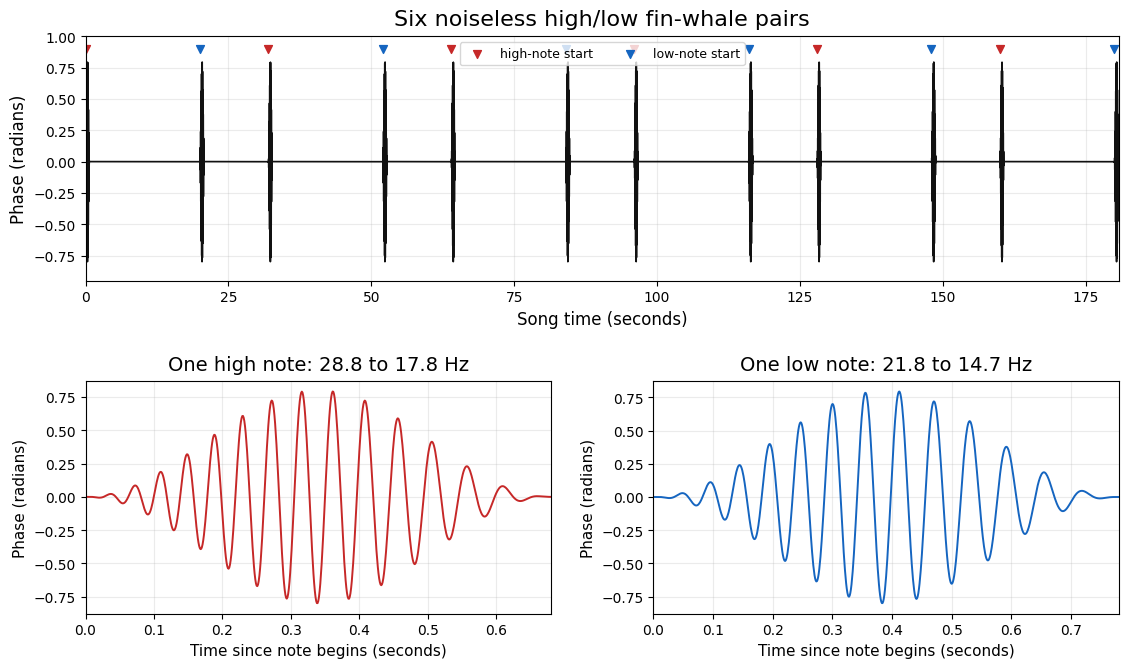

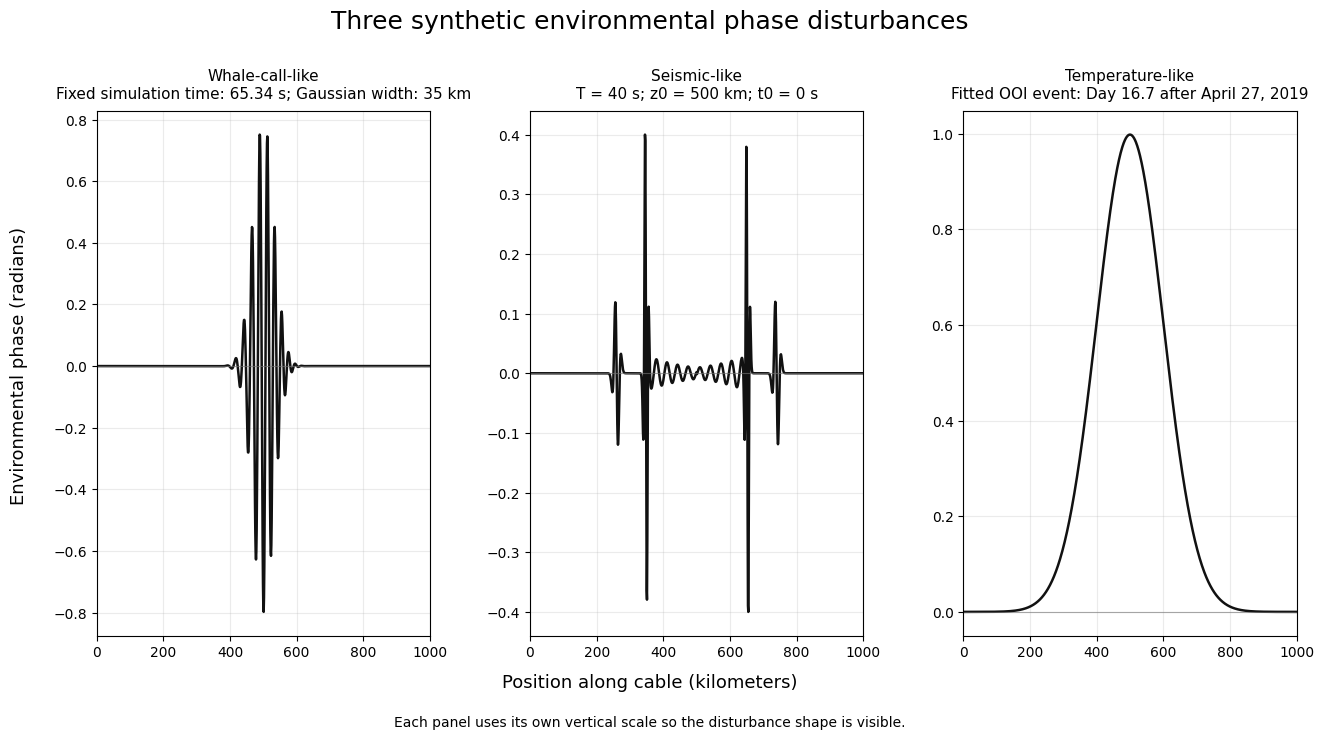

In [6]:
# First show the complete song and then zoom in on one high note and one low note.
fig = plt.figure(figsize=(13.333, 7.5))
grid = fig.add_gridspec(
    2,
    2,
    height_ratios=(1.05, 1.0),
    hspace=0.42,
    wspace=0.22,
)
overview_ax = fig.add_subplot(grid[0, :])
high_ax = fig.add_subplot(grid[1, 0])
low_ax = fig.add_subplot(grid[1, 1])

overview_ax.plot(
    whale_time_s,
    whale_trace_rad,
    color="#111111",
    linewidth=1.2,
)
overview_ax.set_title(
    "Six noiseless high/low fin-whale pairs",
    fontsize=16,
    pad=8,
)
overview_ax.set_xlim(0.0, whale_song_end_s)
overview_ax.set_ylabel("Phase (radians)", fontsize=12)
overview_ax.set_xlabel("Song time (seconds)", fontsize=12)
overview_ax.grid(alpha=0.25)

# Mark the note starts so the alternating 20- and 12-second gaps are visible.
high_starts_s = song_cycle_s*np.arange(M+1)
low_starts_s = high_starts_s+low_note_offset_s
overview_ax.scatter(
    high_starts_s,
    np.full_like(high_starts_s, 0.9),
    color="#C62828",
    marker="v",
    s=32,
    label="high-note start",
)
overview_ax.scatter(
    low_starts_s,
    np.full_like(low_starts_s, 0.9),
    color="#1565C0",
    marker="v",
    s=32,
    label="low-note start",
)
overview_ax.set_ylim(-0.95, 1.0)
overview_ax.legend(loc="upper center", ncol=2, fontsize=9)

high_note_time_s = np.arange(0.0, 0.68+whale_time_step_s, whale_time_step_s)
high_ax.plot(
    high_note_time_s,
    whale_phase_amplitude_rad*P_H(high_note_time_s),
    color="#C62828",
    linewidth=1.4,
)
high_ax.set_title(
    "One high note: 28.8 to 17.8 Hz",
    fontsize=14,
    pad=8,
)
high_ax.set_xlim(0.0, 0.68)
high_ax.set_xlabel("Time since note begins (seconds)", fontsize=11)
high_ax.set_ylabel("Phase (radians)", fontsize=11)
high_ax.grid(alpha=0.25)

low_note_time_s = np.arange(0.0, 0.78+whale_time_step_s, whale_time_step_s)
low_ax.plot(
    low_note_time_s,
    whale_phase_amplitude_rad*P_L(low_note_time_s),
    color="#1565C0",
    linewidth=1.4,
)
low_ax.set_title(
    "One low note: 21.8 to 14.7 Hz",
    fontsize=14,
    pad=8,
)
low_ax.set_xlim(0.0, 0.78)
low_ax.set_xlabel("Time since note begins (seconds)", fontsize=11)
low_ax.set_ylabel("Phase (radians)", fontsize=11)
low_ax.grid(alpha=0.25)

fig.savefig(
    "OFDR_Gaussian_Hyperbolic_Whale_Song_preview.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()


# Next plot the exact three spatial fields that are passed into the recovery calculation.
fig, axes = plt.subplots(
    1,
    3,
    figsize=(13.333, 7.5),
    sharex=False,
)

# The loop uses each disturbance's own limits and description while keeping the plot style fixed.
for ax, family_name in zip(axes, families):
    family = families[family_name]
    true_curve = family["field"]

    ax.plot(
        z_km,
        true_curve,
        color="#111111",
        linewidth=1.8,
    )
    ax.axhline(
        0.0,
        color="#777777",
        linewidth=0.8,
        alpha=0.6,
    )

    ax.set_title(
        f"{family_name}\n{family['context']}",
        fontsize=11,
        pad=9,
    )
    ax.set_xlim(*family["xlim"])
    ax.tick_params(labelsize=10)
    ax.grid(alpha=0.25)

fig.suptitle(
    "Three synthetic environmental phase disturbances",
    fontsize=18,
    y=0.975,
)
fig.supxlabel(
    "Position along cable (kilometers)",
    fontsize=13,
    y=0.065,
)
fig.supylabel(
    "Environmental phase (radians)",
    fontsize=13,
    x=0.02,
)
fig.text(
    0.5,
    0.025,
    "Each panel uses its own vertical scale so the disturbance shape is visible.",
    ha="center",
    va="center",
    fontsize=10,
)
fig.subplots_adjust(
    left=0.085,
    right=0.985,
    bottom=0.14,
    top=0.84,
    wspace=0.30,
)
fig.savefig(
    "OFDR_Environmental_Disturbances_Gaussian_Hyperbolic_Seismic_Simple_Coda_preview.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()


### Explicit fin-whale equations used in the code

For \(j\in\{H,L\}\), the paper-based instantaneous frequency is

$$
f_j(x)
=
\frac{f_{j,0}f_{j,1}D_j}
{(f_{j,0}-f_{j,1})x+f_{j,1}D_j}.
$$

Its accumulated phase in cycles is

$$
\Phi_j(x)
=
\frac{f_{j,0}f_{j,1}D_j}{f_{j,0}-f_{j,1}}
\ln\left(
1+
\frac{(f_{j,0}-f_{j,1})x}{f_{j,1}D_j}
\right).
$$

One smoothly tapered note is

$$
P_j(x)
=
\begin{cases}
\displaystyle
\sin^2\left(\frac{\pi x}{D_j}\right)
\cos\bigl(2\pi\Phi_j(x)\bigr),
&0\le x\le D_j,\\[6pt]
0,&\text{otherwise}.
\end{cases}
$$

The parameters are

| Note | \(f_{j,0}\) | \(f_{j,1}\) | \(D_j\) |
|---|---:|---:|---:|
| High \(H\) | \(28.8\) Hz | \(17.8\) Hz | \(0.68\) s |
| Low \(L\) | \(21.8\) Hz | \(14.7\) Hz | \(0.78\) s |

The complete temporal song is

$$
S(t)
=
\sum_{m=0}^{5}
\left[
P_H(t-32m)
+
P_L\bigl(t-(32m+20)\bigr)
\right].
$$

For the spatial snapshot, define

$$
C(z)
=
\exp\left[
-\frac12\left(\frac{z-500}{35}\right)^2
\right],
\qquad
u(z,T)=T-1-0.002(z-500).
$$

The plotted target is

$$
\boxed{
g_{\mathrm{whale}}(z,T)
=
0.8\,C(z)\,S\bigl(u(z,T)\bigr).
}
$$

The hyperbolic form and note parameters are from Goestchel, Wilcock, and
Abadi (2025). The \(20/12\)-second timing is from the Hawaiian pattern
reported by Helble et al. (2020).

The remaining parts retain the useful features of the original synthetic
model:

- \(0.8\) rad is the selected simulation phase scale;
- \(C(z)\) is a Gaussian localization with assumed center \(500\) km and
  assumed width \(35\) km;
- \(\sin^2(\pi x/D_j)\) is a chosen smooth note taper;
- \(1\) s is a chosen initial offset;
- \(0.002\) s/km is a chosen slow spatial-shift coefficient.

Those five values are modeling choices, not empirical fin-whale or
source-to-cable measurements.


## 5. Simulate one fiber and recover each fixed spatial target

The code below generates two fixed Rayleigh-scattering profiles, computes the
matched-filtered returns, and applies conjugate-product phase recovery.

The random scatterer profiles are part of the synthetic fiber model and are
held fixed by a seed. No laser-phase noise, environmental noise, or additive
receiver noise is included.


In [7]:

# --- Synthetic Rayleigh-scattering profiles ---
def reflection_profile(rng):
    """Generate one random complex backscatter profile."""
    # Every cable position gets a random phase and signed random amplitude.
    random_phase = rng.uniform(0.0, 2*np.pi, size=num_ranges)
    random_amplitude = rng.normal(size=num_ranges)
    # The exponential factor makes the returned amplitude decrease with distance along the cable.
    attenuation = np.sqrt(np.exp(-alpha*z_km*1000.0))
    return random_amplitude*attenuation*np.exp(1j*random_phase)


def matched_output(profile, interrogation):
    """Simulate the returned signal and apply its matched filter."""
    # Convolving the scatterer profile with the interrogation pulse adds the returns from all positions.
    returned_full = fftconvolve(
        profile,
        interrogation,
        mode="full",
    )*dt_tau
    returned = returned_full[:num_ranges]

    # Correlate the return with the transmitted pulse by convolving with its reversed conjugate.
    matched_full = fftconvolve(
        returned,
        np.conj(interrogation[::-1]),
        mode="full",
    )*dt_fast
    start = len(interrogation)-1
    return matched_full[start:start+num_ranges]


# --- Environmental-phase recovery ---
def recover_field(
    h_x,
    h_y,
    true_field,
    interrogation,
    m_ideal_x,
    m_ideal_y,
):
    """Recover phase by comparing perturbed and baseline returns."""
    # Multiplication by exp(i*g) adds the environmental phase g to the fixed backscatter.
    phase_factor = np.exp(1j*true_field)
    m_pert_x = matched_output(
        h_x*phase_factor,
        interrogation,
    )
    m_pert_y = matched_output(
        h_y*phase_factor,
        interrogation,
    )
    # Conjugate-and-add combines both polarizations without dividing by a small baseline value.
    combined = (
        m_pert_x*np.conj(m_ideal_x)
        + m_pert_y*np.conj(m_ideal_y)
    )
    return np.angle(combined)


# Generate the two polarization profiles once and reuse them for all signals and disturbances.
# The seed makes this simulated fiber exactly reproducible.
fiber_seed = 100
rng_fiber = np.random.default_rng(fiber_seed)
h_x = reflection_profile(rng_fiber)
h_y = reflection_profile(rng_fiber)

# Compute the baseline matched-filter outputs once for each interrogation signal.
ideal_outputs = {}
for signal_name, (_, interrogation) in signal_samples.items():
    ideal_outputs[(signal_name, "x")] = matched_output(
        h_x,
        interrogation,
    )
    ideal_outputs[(signal_name, "y")] = matched_output(
        h_y,
        interrogation,
    )

# Now apply each of the three environmental phases and recover it with each of the four signals.
recovered = {}
for family_name, family in families.items():
    for signal_name, (_, interrogation) in signal_samples.items():
        recovered[(family_name, signal_name)] = recover_field(
            h_x,
            h_y,
            family["field"],
            interrogation,
            ideal_outputs[(signal_name, "x")],
            ideal_outputs[(signal_name, "y")],
        )

print("Finished all 12 fixed-snapshot family-signal comparisons")


Finished all 12 fixed-snapshot family-signal comparisons


## 6. Slide-ready spatial recovery results

The results are split into three separate \(2\times2\), 16:9 figures, one for
each environmental perturbation:

- the true perturbation is a solid black line;
- the recovered perturbation is a dashed blue line;
- only the interrogation signal changes between panels.

Each panel reports wrapped-phase RMSE over the displayed spatial window:

$$
\operatorname{RMSE}
=
\sqrt{
\frac{1}{N_{\mathrm{view}}}
\sum_{j\in\mathrm{view}}
\left[
\arg\left(e^{i(\widehat g_j-g_j)}\right)
\right]^2
}.
$$

For the whale recovery figure, the displayed window is 350--650 km so the
Gaussian-localized wave packet is visible.


In [8]:

# Keep the signal order the same in every 2-by-2 comparison.
signal_names = list(signal_samples)

recovery_preview_paths = {
    "Whale-call-like": "OFDR_Whale_Gaussian_Hyperbolic_Recovery_2x2_preview.png",
    "Seismic-like": "OFDR_Seismic_Simple_Coda_Recovery_2x2_preview.png",
    "Temperature-like": "OFDR_Temperature_Recovery_2x2_preview.png",
}


def wrapped_phase_rmse(estimate, truth):
    """Measure phase error while treating angles differing by 2*pi as equal."""
    phase_error = np.angle(
        np.exp(1j*(np.asarray(estimate)-np.asarray(truth)))
    )
    return np.sqrt(np.mean(phase_error**2))


def make_recovery_slide(family_name):
    """Make one four-panel recovery comparison for a disturbance."""
    family = families[family_name]
    true_curve = family["field"]
    context_label = family["context"]
    # Calculate the reported RMSE only over the position window shown in the panels.
    display_mask = (
        (z_km >= family["recovery_xlim"][0])
        & (z_km <= family["recovery_xlim"][1])
    )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(13.333, 7.5),
        sharex=True,
        sharey=True,
    )
    axes = axes.ravel()

    legend_handles = None

    # Only the interrogation signal changes from one panel to the next.
    for ax, signal_name in zip(axes, signal_names):
        recovered_curve = recovered[
            (family_name, signal_name)
        ]
        rmse = wrapped_phase_rmse(
            recovered_curve[display_mask],
            true_curve[display_mask],
        )

        true_line, = ax.plot(
            z_km,
            true_curve,
            color="#111111",
            linewidth=1.8,
            label="True perturbation",
        )
        recovered_line, = ax.plot(
            z_km,
            recovered_curve,
            color="#1565C0",
            linewidth=1.5,
            linestyle="--",
            label="Recovered perturbation",
        )

        if legend_handles is None:
            legend_handles = [
                true_line,
                recovered_line,
            ]

        ax.set_title(
            f"{signal_name}\n"
            f"spatial phase RMSE = {rmse:.4g} rad",
            fontsize=13,
            pad=7,
        )
        ax.tick_params(labelsize=10)
        ax.grid(alpha=0.25)
        ax.set_xlim(*family["recovery_xlim"])

    fig.suptitle(
        f"{family_name} perturbation recovery",
        fontsize=18,
        y=0.985,
    )
    fig.text(
        0.5,
        0.925,
        context_label,
        ha="center",
        va="center",
        fontsize=11,
    )
    fig.legend(
        legend_handles,
        ["True perturbation", "Recovered perturbation"],
        loc="upper center",
        bbox_to_anchor=(0.5, 0.895),
        ncol=2,
        frameon=False,
        fontsize=11,
    )
    fig.supxlabel(
        "Position along cable (kilometers)",
        fontsize=13,
        y=0.035,
    )
    fig.supylabel(
        "Differential optical phase (radians)",
        fontsize=13,
        x=0.02,
    )
    fig.subplots_adjust(
        left=0.09,
        right=0.985,
        bottom=0.12,
        top=0.79,
        hspace=0.42,
        wspace=0.16,
    )
    # Save a separate report-ready image for this disturbance.
    fig.savefig(
        recovery_preview_paths[family_name],
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()


### Whale-call spatial recovery: four interrogation signals


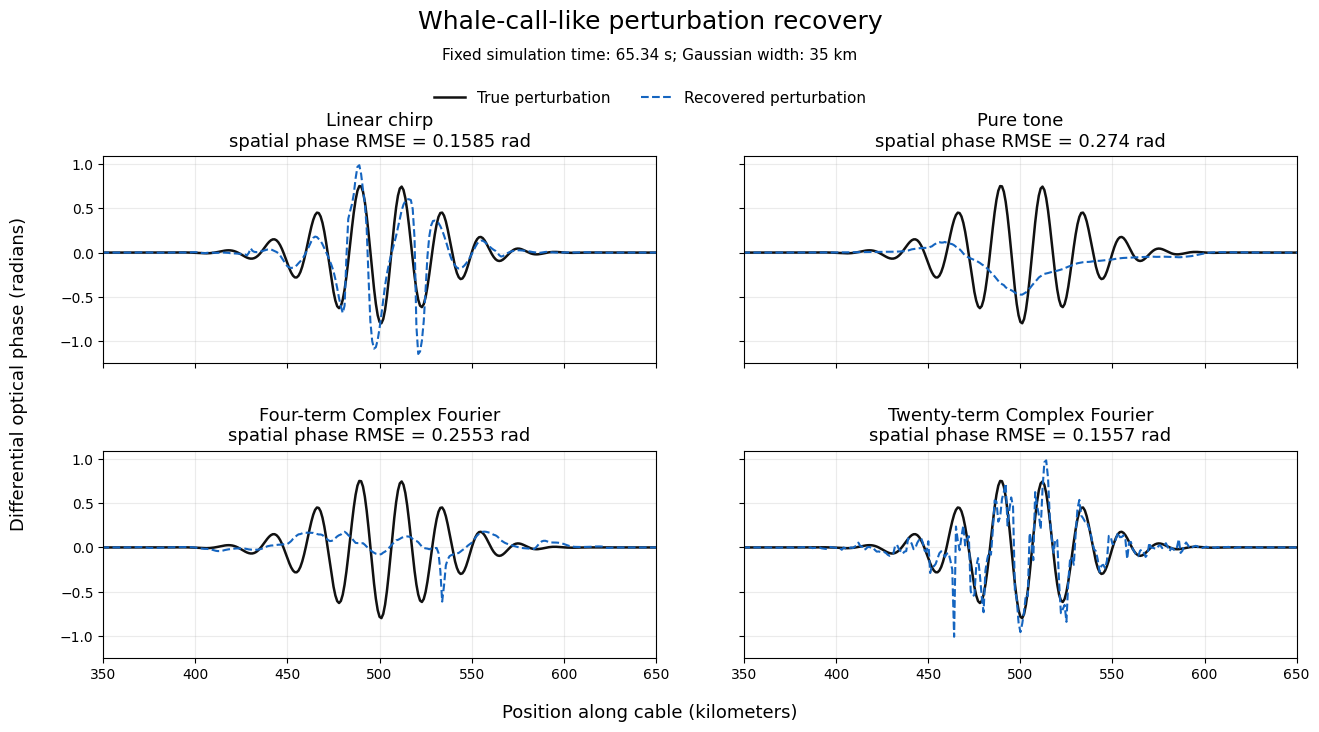

In [9]:
# Make the four-signal comparison for the whale disturbance.
make_recovery_slide("Whale-call-like")


### Seismic spatial recovery: four interrogation signals


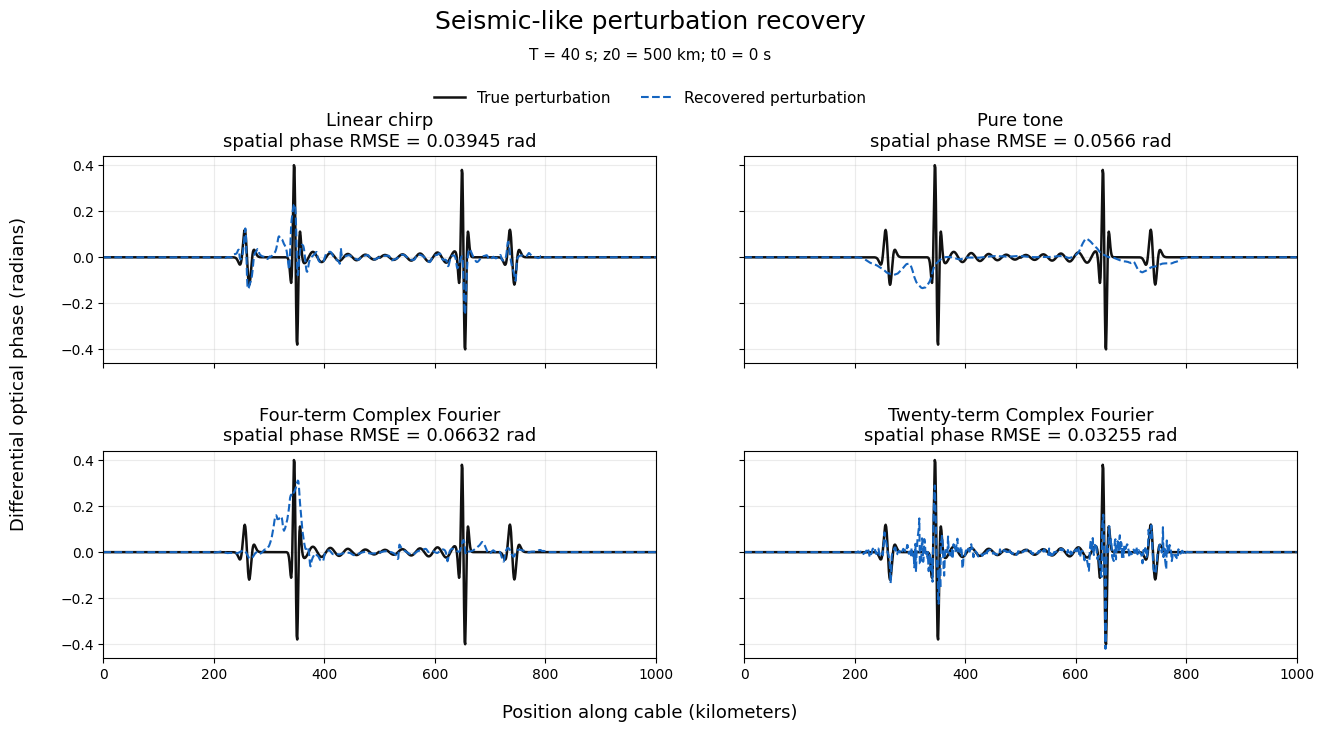

In [10]:
# Make the four-signal comparison for the seismic disturbance.
make_recovery_slide("Seismic-like")


### Temperature spatial recovery: four interrogation signals


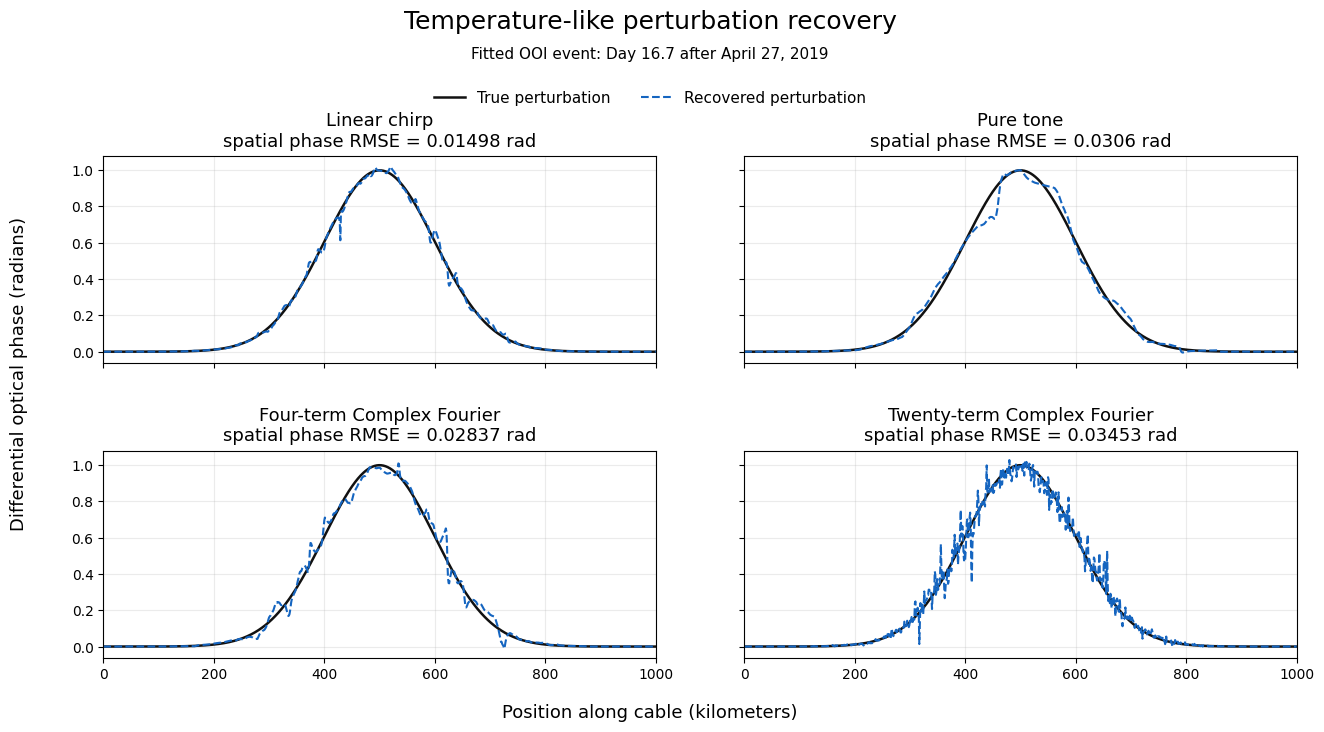

In [11]:
# Make the four-signal comparison for the temperature disturbance.
make_recovery_slide("Temperature-like")


## What is being plotted?

Every recovery figure plots

$$
\widehat g(z,T_0),
$$

so the environmental observation time is fixed and position changes along
the horizontal axis.

- At \(T_0=65.34\) s, the whale panel shows the third high note spread across
  position by the original \(0.002\) s/km synthetic shift and localized by
  the 35-km Gaussian.
- At 40 s, the seismic-like snapshot shows the symmetric P- and S-wavefront structures followed by one damped
  coda term along the cable.
- At Day 16.7 after April 27, 2019, the temperature-like snapshot shows the broad affected region
  centered near 500 km.

The colored curves are recovered phase \(\widehat g\), not raw optical return.
The whale model is intentionally idealized: its hyperbolic note shapes and
\(20/12\)-second timing are paper-based, while its Gaussian localization,
smooth taper, slow spatial shift, and amplitude are explicit simulation
choices. No environmental interference or added noise is included here.
